In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from numba import njit
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks.ddms import DDM
from simulators.benchmarks.ddms import sample_ddm_prior

In [3]:
parameter_names = [
    "v_intercept", "v_slope", "s_v",
    "a_intercept", "a_slope", "decay",
    "tau", "s_tau",
]

In [4]:
context_manager = ContextManager(parameter_names=parameter_names)

In [5]:
num_samples = 500
design_matrix = np.random.normal(0.0, 1.0, size=(num_samples, 2)).astype(np.float32)

In [6]:
model_family = NestedModelFamily(
    name="ddm",
    model=DDM,
    context_manager=context_manager,
    prior_fun=sample_ddm_prior,
    num_samples=num_samples
)

### Priors

In [10]:
# Run multiple configs in one go
configs = [
    {"s_v", "s_tau"},                # fix variability terms
    {"s_v"},
    {"s_tau"},# fix only s_v
    set(),                           # all free
    {"v_intercept", "a_slope"},       # cfg1: zero out these
    {"tau", "s_tau", "decay"},        # cfg2: zero out these
]

context_variables={
    "x_v": design_matrix[:, 0],
    "x_a": design_matrix[:, 1],
}

In [11]:
results = model_family.sample(configs, context=context_variables)

{'v_intercept': 0.8457267880439758, 'v_slope': -3.92568039894104, 's_v': 0.0, 'a_intercept': 4.058361053466797, 'a_slope': -0.45314842462539673, 'decay': 0.11428254842758179, 'tau': 0.7002758979797363, 's_tau': 0.0}
{'v_intercept': 2.6092660427093506, 'v_slope': -1.8078831434249878, 's_v': 0.0, 'a_intercept': 3.1563074588775635, 'a_slope': -0.002984290709719062, 'decay': 0.08638978004455566, 'tau': 0.5087886452674866, 's_tau': 0.36911165714263916}
{'v_intercept': 0.5600160956382751, 'v_slope': -1.0810099840164185, 's_v': 0.17809368669986725, 'a_intercept': 2.326608180999756, 'a_slope': 0.2724076509475708, 'decay': 0.6259701251983643, 'tau': 0.4679778516292572, 's_tau': 0.0}
{'v_intercept': 2.0879359245300293, 'v_slope': -2.3641974925994873, 's_v': 0.13503779470920563, 'a_intercept': 1.316470980644226, 'a_slope': -1.065256953239441, 'decay': 0.23316702246665955, 'tau': 0.3413006663322449, 's_tau': 0.32882046699523926}
{'v_intercept': 0.0, 'v_slope': -2.265160083770752, 's_v': 0.08308015

In [12]:
results

[{'variant_name': 'ddm|cfg1',
  'fixed_parameters': ['s_v', 's_tau'],
  'mask': {'v_intercept': 1.0,
   'v_slope': 1.0,
   's_v': 0.0,
   'a_intercept': 1.0,
   'a_slope': 1.0,
   'decay': 1.0,
   'tau': 1.0,
   's_tau': 0.0},
  'prior_draw': array([ 0.8457268 , -3.9256804 ,  0.06082314,  4.058361  , -0.45314842,
          0.11428255,  0.7002759 ,  0.73473185], dtype=float32),
  'full_params': {'v_intercept': 0.8457267880439758,
   'v_slope': -3.92568039894104,
   's_v': 0.0,
   'a_intercept': 4.058361053466797,
   'a_slope': -0.45314842462539673,
   'decay': 0.11428254842758179,
   'tau': 0.7002758979797363,
   's_tau': 0.0},
  'sim_data': {'rts': array([ 2.1952758 ,  1.0292759 ,  5.226276  ,  1.0122759 ,  0.9322759 ,
           1.3092759 ,  0.8982759 ,  2.4282758 ,  2.397276  ,  0.9902759 ,
           4.320276  ,  0.9502759 ,  1.413276  ,  7.274276  ,  4.8212757 ,
           0.9782759 ,  0.8172759 ,  1.1512759 ,  5.1762757 ,  1.0392759 ,
           0.9592759 ,  1.2062759 ,  1.5862759

In [24]:
rts_list = []
titles = []
for i, res in enumerate(results, 1):
    fp = res["full_params"]
    sim = res["sim_data"]
    assert "rts" in sim and "choices" in sim
    assert sim["rts"].shape == (num_samples,)
    assert sim["choices"].shape == (num_samples,)
    rts = sim["rts"]
    # Filter out timeouts if any (-1.0)
    rts = rts[rts > 0]
    rts_list.append(rts)
    titles.append(f"Config {i}")

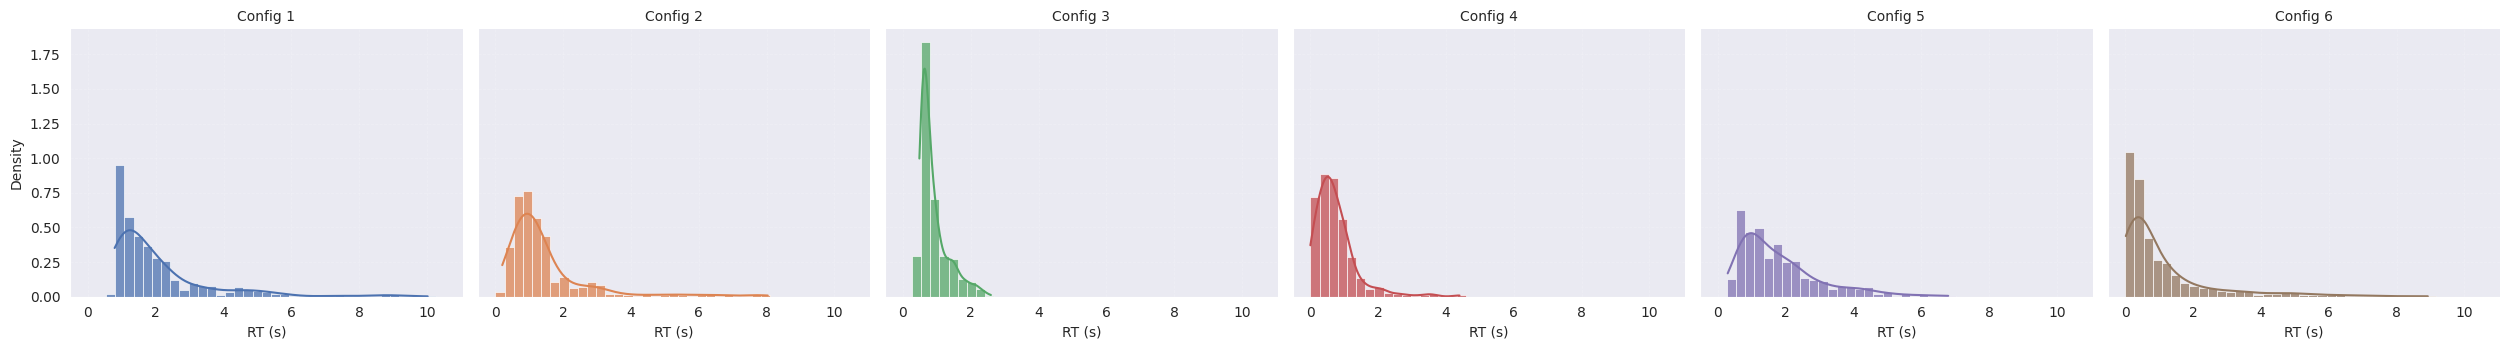

In [25]:
n = len(rts_list)
fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.6), sharey=True)
if n == 1:
    axes = [axes]

bins = np.linspace(0.0, max(max(r) for r in rts_list)*1.05, 40)
palette = sns.color_palette("deep", n)

for ax, rts, title, color in zip(axes, rts_list, titles, palette):
    sns.histplot(rts, bins=bins, stat="density", ax=ax,
                 color=color, alpha=0.75, edgecolor=None, kde=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("RT (s)")
    ax.grid(alpha=0.2, linestyle="--", linewidth=0.6)
    sns.despine(ax=ax)

axes[0].set_ylabel("Density")
fig.tight_layout()